# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?

A standard linear model is not equipped to model non-linear relationships. Additionally, outputs are unbounded, and thus cannot represent probabilities that must be contained between 0 and 1. General linear models deal with these limitations by mapping linear outputs to valid ranges using a link function to ensure that probabilities can be represented. Latent variable models assume that there are underlying variables that influence the observed data, capturing more complex model relationships. Additionally, we are able to use activation functions to represent non-linear relationships.

2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.

Logistic regression outputs probabilities, so using loss functions like binary and categorical cross entropy models are effective in representing the loss and working with these outputted probabilities. BCE utilizes the maximum likelihood estimation concept, which subsequently minimizes cross entropy. When binary cross entropy is used, it heavily penalizes confidently wrong outputs. With categorical cross entropy using softmax outputs, BCE is then generalized to multiple classes and encourages the correct class probability to approach 1.

3. True or false, and explain: Logistic regression is a linear model.

Technically TRUE, because all of the input features are modeled with a linear combination, then passed through a non-linear function to produce the probabilities.

4. True or false, and explain: Logistic regression cannot be used for classification.

FALSE. Logistic regression is actually made for classification, as it outputs a probability that an observation is in a certain class.

5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?

No. The coefficient in logistic regression represents the change in log-odds of the outcome for a 1-unit change in the feature variable.

6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.

FALSE. Logistic regression is still linear in terms of its input features, so the feature engineering is still necessary for the non-linear patterns to be detected.

7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

FALSE. Logistic regression is simply better designed for classification purposes. There are certain situations where ordinary least squares would be the preferred model, such as predicting a continuous variable.


**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

Done below.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

Based on the coefficients, we can conclude that being a debtor highly increases the risk of dropout, while having tuition fees up to date and being a scholarship holder decreases the risk of dropout. Age of enrollment does produce a slight increase in dropout risk as age increases.

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

Based on the scatter plot, the lower age ranges (20-30) are the ones where being up to date on tuition reduces dropout probability the most. In general, being up to date on tuition changes the probability of dropout by almost 62 percent.

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

The model achieves 75.3% accuracy, but it is biased toward predicting non-dropout, leading to many missed at-risk students. Specifically, 191 dropouts were missed.

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

From the visualization, it can be concluded that the logistic regression model and linear models have a similar general shape, with logistic regression spiking at certain values.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

Students that are of older age with tuition fees NOT up to date, as well as curriculum units not approved for the 1st semester are more at-risk of dropping out. Some interventions that directly address these issues include greater support for low-income students and more allocation of need-based funding.

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


The confusion matrix shows that the category "Enrolled" was never predicted (hence the second column being all zeroes). Additionally, the hard classification also does not predict every class, as it excludes Enrolled.

                               Feature  Coefficient  Odds Ratio
0                               Debtor     0.555819    1.743368
1              Tuition fees up to date    -2.384962    0.092092
2                   Scholarship holder    -0.859125    0.423532
3                    Age at enrollment     0.056337    1.057954
4  Curricular units 1st sem (approved)    -0.443503    0.641784


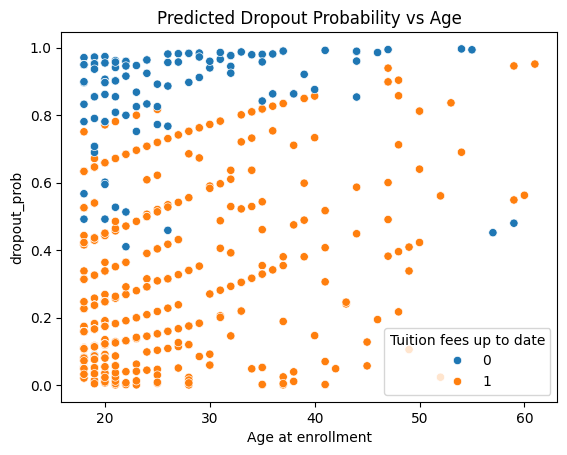

Tuition fees up to date
0    0.860149
1    0.242833
Name: dropout_prob, dtype: float64
0.6173159629308491
[[541  28]
 [191 125]]
0.752542372881356


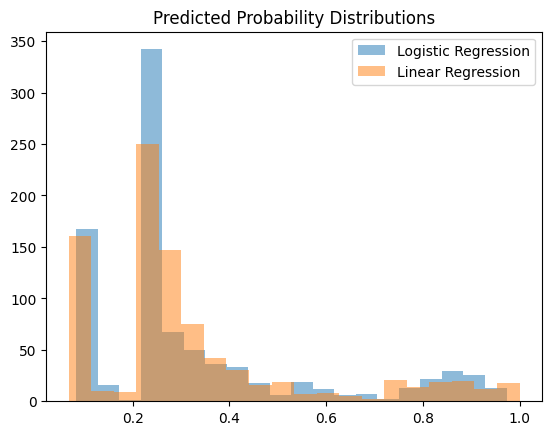

105
      Debtor  Tuition fees up to date  Scholarship holder  Age at enrollment  \
3551       1                        0                   0                 33   
3773       1                        0                   1                 26   
2767       0                        0                   0                 24   
3195       0                        0                   0                 18   
3340       0                        0                   0                 19   

      Curricular units 1st sem (approved)  dropout_prob  
3551                                    0      0.987016  
3773                                    0      0.955954  
2767                                    0      0.963318  
3195                                    0      0.949313  
3340                                    0      0.951957  
[[206   0 110]
 [ 39   0 112]
 [ 18   0 400]]
0.6847457627118644
['Dropout' 'Enrolled' 'Graduate']
[[0.68113991 0.2101235  0.10873659]
 [0.1718503  0.21387239 0.614277

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

# QUESTION 1
df = pd.read_csv("data.csv", sep=";")

df["Target_binary"] = df["Target"].apply(lambda x: 1 if x == "Dropout" else 0)

features = [
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment",
    "Curricular units 1st sem (approved)"
]

X = df[features]
y = df["Target_binary"]

df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

# QUESTION 2
model = LogisticRegression(max_iter=1000)
model.fit(df_train[features], df_train["Target_binary"])

results = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_[0],
    "Odds Ratio": np.exp(model.coef_[0])
})

print(results)

# QUESTION 3
df_test["dropout_prob"] = model.predict_proba(df_test[features])[:, 1]

plt.figure()
sns.scatterplot(
    data=df_test,
    x="Age at enrollment",
    y="dropout_prob",
    hue="Tuition fees up to date"
)
plt.title("Predicted Dropout Probability vs Age")
plt.show()

avg_by_tuition = df_test.groupby("Tuition fees up to date")["dropout_prob"].mean()
print(avg_by_tuition)
print(avg_by_tuition[0] - avg_by_tuition[1])

# QUESTION 4
X_logit = df_train[
    ["Debtor", "Tuition fees up to date", "Scholarship holder", "Age at enrollment"]
]
y_train = df_train["Target_binary"]
X_test = df_test[
    ["Debtor", "Tuition fees up to date", "Scholarship holder", "Age at enrollment"]
]
y_test = df_test["Target_binary"]

logit = LogisticRegression(max_iter=1000)
logit.fit(X_logit, y_train)

y_pred_class = logit.predict(X_test)

cm = confusion_matrix(y_test, y_pred_class)
acc = accuracy_score(y_test, y_pred_class)

print(cm)
print(acc)

# QUESTION 5
lin = LinearRegression()
lin.fit(X_logit, y_train)

logit_probs = logit.predict_proba(X_test)[:, 1]
lin_probs = np.clip(lin.predict(X_test), 0, 1)

plt.figure()
plt.hist(logit_probs, bins=20, alpha=0.5, label="Logistic Regression")
plt.hist(lin_probs, bins=20, alpha=0.5, label="Linear Regression")
plt.legend()
plt.title("Predicted Probability Distributions")
plt.show()

df_test["risk_flag"] = logit_probs > 0.7

high_risk = df_test[df_test["risk_flag"] == True]
print(len(high_risk))
print(high_risk[features + ["dropout_prob"]].head())

# QUESTION 6
X_multi = df_train[
    ["Debtor", "Tuition fees up to date", "Curricular units 1st sem (approved)"]
]
y_multi = df_train["Target"]

X_test_m = df_test[
    ["Debtor", "Tuition fees up to date", "Curricular units 1st sem (approved)"]
]
y_test_m = df_test["Target"]

multi = LogisticRegression(multi_class="multinomial", max_iter=1000)
multi.fit(X_multi, y_multi)

y_pred_multi = multi.predict(X_test_m)

cm_multi = confusion_matrix(y_test_m, y_pred_multi, labels=multi.classes_)
print(cm_multi)
print(accuracy_score(y_test_m, y_pred_multi))

probs_multi = multi.predict_proba(X_test_m)

print(multi.classes_)
print(probs_multi[:5])

print(np.unique(y_pred_multi))
print(set(y_test_m.unique()).issubset(set(np.unique(y_pred_multi))))

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

Done below.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

The drug coefficient is negative, meaning that the drug does NOT improve survival probability. The bilirubin coefficient is also negative, meaning that higher bilirubin predicts a lower survival rate. Additionally, a higher presentation of edema leads to a greater decrease in life expectancy.


3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

There isn't any specific range of bilirubin values that shows a definite improvement when the drug is introduced. The average drug effect on survival probability was computed to be -0.0189, meaning that drug users would have a *lower* predicted survival rate of 1.89%, indicating a negligible difference.


4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

Accuracy is 0.7468.

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

Logistic regression produces more precise predictions and bounded probabilities, while the linear model produces invalid probability values with wider bar sizes. Therefore, logistic regression is preferred for classification probability estimation.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

While the model assigns probability mass to all four stages, the hard classifier only predicts stages 3 and 4 as indicated by the confusion matrix. This means that the features aren't good enough to predict the disease in its early stages.

Missing values per column:
Status         0
Edema          0
Drug         106
Bilirubin      0
Stage          6
dtype: int64
Remaining rows after dropna: 312

Logistic Regression Coefficients:
Edema -0.915294732820148
Drug -0.22346942348012627
Bilirubin -0.34858379108408066
Average drug effect on survival probability: -0.018907671240633528


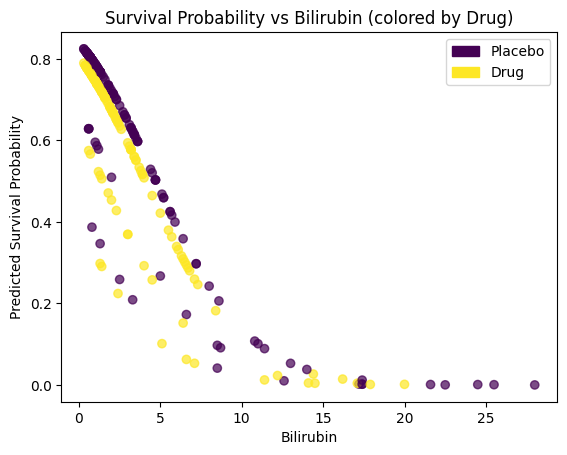


Confusion Matrix:
[[ 60  65]
 [ 14 173]]
Accuracy: 0.7467948717948718


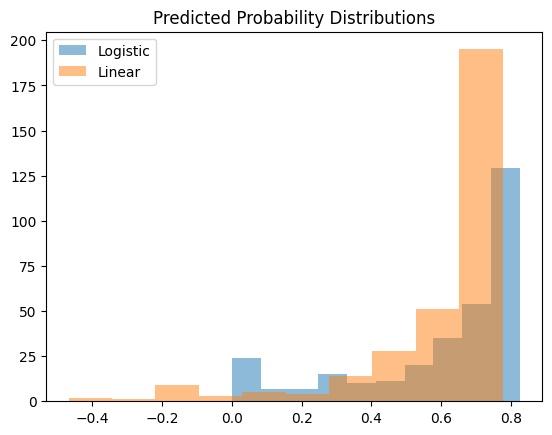


Stage Model Confusion Matrix:
[[  0   0  16   0]
 [  0   0  61   6]
 [  0   0 102  18]
 [  0   0  74  35]]

Classes predicted by hard classifier:
[3. 4.]

Do probabilities cover all classes (nonzero columns)?
[ True  True  True  True]

First 5 probability rows:
[[3.66170715e-06 2.62122259e-02 1.63752787e-01 8.10031326e-01]
 [7.35327271e-02 2.52874829e-01 4.00994448e-01 2.72597996e-01]
 [2.68744383e-02 1.72053828e-01 3.37699672e-01 4.63372062e-01]
 [2.14080082e-02 1.67391080e-01 3.38389510e-01 4.72811402e-01]
 [2.09867223e-02 2.27849665e-01 4.28140451e-01 3.23023162e-01]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [18]:
import matplotlib.patches as mpatches

# QUESTION 1

df = pd.read_csv("cirrhosis.csv")

cols = ["Status", "Edema", "Drug", "Bilirubin", "Stage"]
df = df[cols]

print("Missing values per column:")
print(df.isna().sum())

df = df.dropna()
print("Remaining rows after dropna:", len(df))

# Encode variables
df["Status"] = df["Status"].map({"C": 1, "CL": 1, "D": 0})
df["Edema"] = df["Edema"].map({"N": 0, "S": 1, "Y": 2})
df["Drug"] = df["Drug"].map({"Placebo": 0, "D-penicillamine": 1})


# QUESTION 2

X = df[["Edema", "Drug", "Bilirubin"]]
y = df["Status"]

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X, y)

print("\nLogistic Regression Coefficients:")
for name, coef in zip(X.columns, log_model.coef_[0]):
    print(name, coef)

# QUESTION 3
df["pred_prob"] = log_model.predict_proba(X)[:, 1]

drug_effect = (
    df[df["Drug"] == 1]["pred_prob"].mean()
    - df[df["Drug"] == 0]["pred_prob"].mean()
)

print("Average drug effect on survival probability:", drug_effect)

plt.figure()

scatter = plt.scatter(
    df["Bilirubin"],
    df["pred_prob"],
    c=df["Drug"],
    alpha=0.7
)

plt.xlabel("Bilirubin")
plt.ylabel("Predicted Survival Probability")
plt.title("Survival Probability vs Bilirubin (colored by Drug)")

legend_labels = {
    0: "Placebo",
    1: "Drug"
}

handles = [
    mpatches.Patch(color=scatter.cmap(scatter.norm(k)), label=v)
    for k, v in legend_labels.items()
]

plt.legend(handles=handles)
plt.show()


# QUESTION 4

y_pred = log_model.predict(X)

cm = confusion_matrix(y, y_pred)
acc = accuracy_score(y, y_pred)

print("\nConfusion Matrix:")
print(cm)
print("Accuracy:", acc)

# QUESTION 5

lin_model = LinearRegression()
lin_model.fit(X, y)

df["logit_prob"] = log_model.predict_proba(X)[:, 1]
df["lin_prob"] = lin_model.predict(X)
df["lin_prob_clipped"] = df["lin_prob"].clip(0, 1)

plt.figure()
plt.hist(df["logit_prob"], alpha=0.5, label="Logistic")
plt.hist(df["lin_prob"], alpha=0.5, label="Linear")
plt.legend()
plt.title("Predicted Probability Distributions")
plt.show()

# QUESTION 6

X2 = df[["Edema", "Bilirubin"]]
y2 = df["Stage"]

stage_model = LogisticRegression(max_iter=1000, multi_class="multinomial")
stage_model.fit(X2, y2)

y2_pred = stage_model.predict(X2)
cm2 = confusion_matrix(y2, y2_pred)

print("\nStage Model Confusion Matrix:")
print(cm2)

print("\nClasses predicted by hard classifier:")
print(np.unique(y2_pred))

probs = stage_model.predict_proba(X2)

print("\nDo probabilities cover all classes (nonzero columns)?")
print((probs.sum(axis=0) > 0))

print("\nFirst 5 probability rows:")
print(probs[:5])

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

The derivative with respect to the $k$-th feature is simply $b_k$, meaning that a 1 unit increase in $x_k$ changes the prediction by $b_k$.

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

If we let $L=bx$, then we can get the following:

$$
\hat{p} = \frac{e^{b \cdot x}}{1 + e^{b \cdot x}}, \quad L = b \cdot x
$$

$$
\frac{d\hat{p}}{dL} = \hat{p}(1 - \hat{p})
$$

$$
\frac{\partial \hat{p}}{\partial x_k}
= \frac{d\hat{p}}{dL} \cdot \frac{\partial L}{\partial x_k}
= \hat{p}(1 - \hat{p}) \cdot b_k
$$


3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

A 1-unit increase in $x_k$ increases the log-odds by exactly $b_k$.